____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

_______
# Count 

In [19]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0, 1])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[2, 3])


nofilter__swot250naive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [20]:
DS.dropna('row_number')

<xarray.Dataset> Size: 367MB
Dimensions:        (id_comb: 4, row_number: 284677)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 9MB 2023-04-02T06:20:...
    longitude      (id_comb, row_number) float64 9MB 5.176 5.174 ... 1.809 1.808
    latitude       (id_comb, row_number) float64 9MB 42.86 42.86 ... 39.31 39.31
    pass_number    (id_comb, row_number) float64 9MB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 9MB 06:37:27.303464 ...
    cycle_number   (id_comb, row_number) float64 9MB 478.0 478.0 ... 577.0 577.0
    drifter_id     (id_comb, row_number) object 9MB '0-4388554' ... '30053406...
    drifter_type   (id_comb, row_number) object 9MB 'CARTHE' 'CARTHE' ... 'SVP'
    depth          (id_comb, row_number) float64 9MB 0.0 0.0 0.0 ... 15.0 15.0
    phi            (id_comb, row_number) float64 9MB 1.815 1.815 ... -1.802
  * row_number     (row_number) int64 2MB 27 28 29 30 ... 405570 405571 405572
  * id_comb        (id_comb) <U39 624B 'nofilter__swot250naive_etaf__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 9MB -7.969e-05 ... 1.79e-06
    acce           (id_comb, row_number) float64 9MB -2.891e-06 ... -7.179e-06
    exce_acc       (id_comb, row_number) float64 9MB -7.68e-05 ... 8.97e-06
    core           (id_comb, row_number) float64 9MB 2.763e-05 ... 7.729e-06
    exce_cor       (id_comb, row_number) float64 9MB -0.0001073 ... -5.939e-06
    ggde           (id_comb, row_number) float64 9MB -5.935e-05 ... 1.162e-06
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 9MB -1.456e-10 ... -4.019e-11
    prodn_acc_ggd  (id_comb, row_number) float64 9MB 1.879e-10 ... -6.957e-11
    prodn_acc_wd   (id_comb, row_number) float64 9MB -5.05e-11 ... 2.729e-12
    prodn_cor_ggd  (id_comb, row_number) float64 9MB -1.477e-09 ... 5.22e-11
    prodn_cor_wd   (id_comb, row_number) float64 9MB 3.97e-10 ... -2.048e-12
    prodn_ggd_wd   (id_comb, row_number) float64 9MB -5.124e-10 ... -3.545e-12

In [21]:
DSD50 =  DS.where(DS.depth==50, drop=True).isel(id_comb=0)
DSD100 =  DS.where(DS.depth==100, drop=True).isel(id_comb=0)
print('Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m')
print(len(DS.isel(id_comb=0).to_dataframe().dropna()),
      len(DSS.to_dataframe().dropna()),
      len(DSD.to_dataframe().dropna()),
      len(DSD50.to_dataframe().dropna()),
      len(DSD100.to_dataframe().dropna()),
     )


Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m
284677 301210 240026 6476 7583


__________________
## Sensitivity to SWOT-250m filtering

150605
9.528524538330606
9.892475627377918
9.76713788318452
9.86540111989091
7.8209443372082
8.153123829339016
8.0176624629224
8.159763350441974


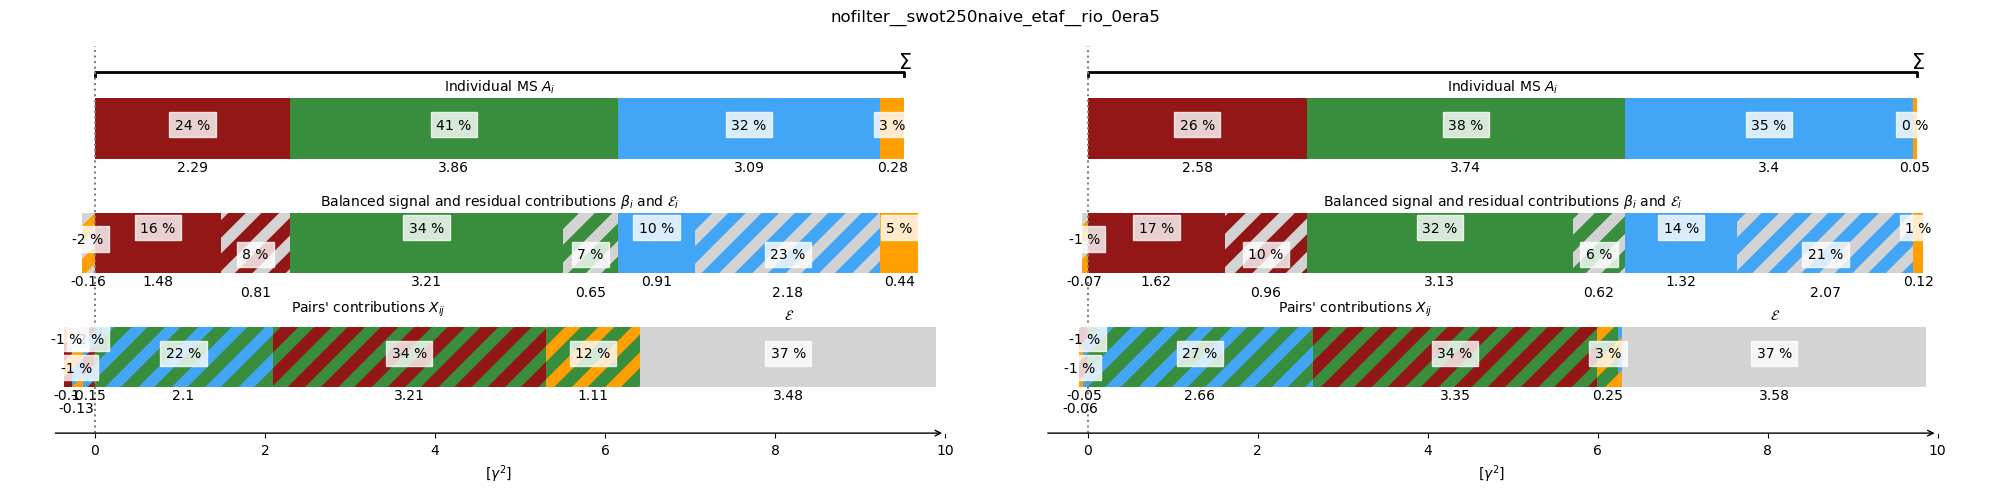

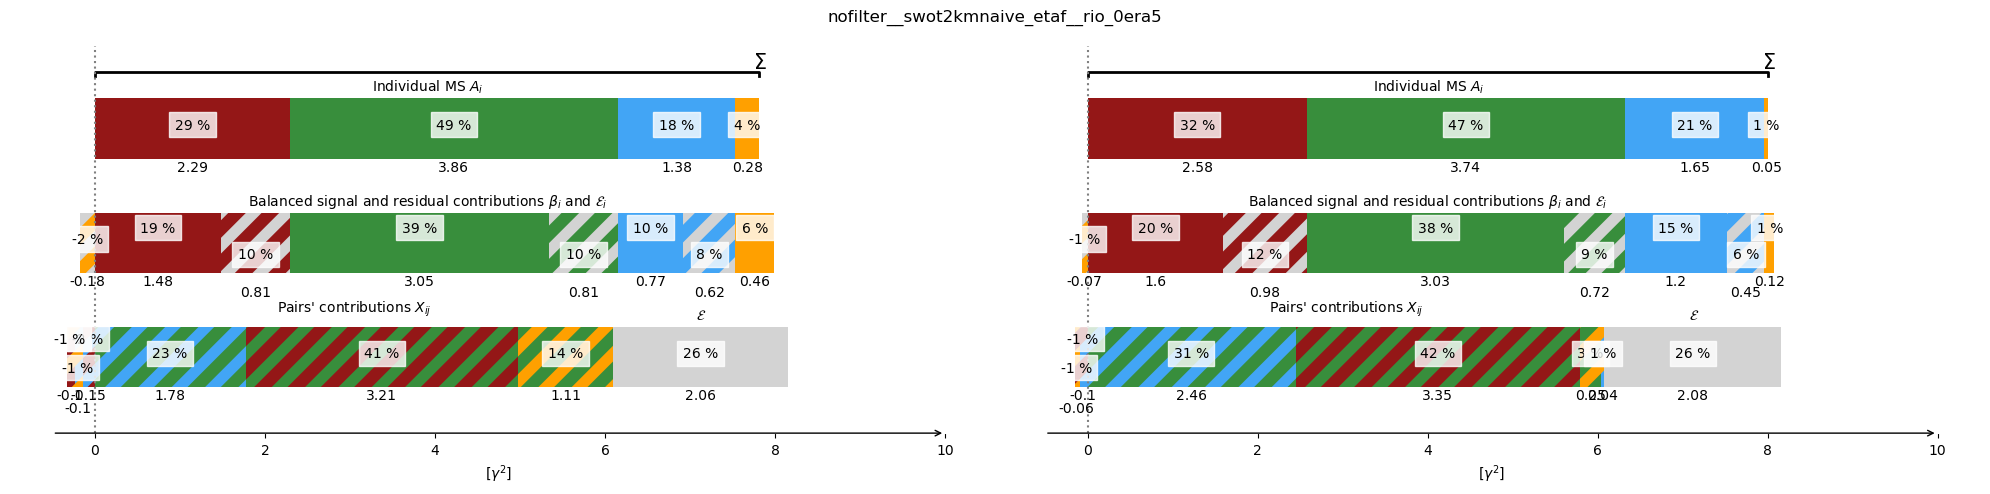

In [22]:
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

120013
5.880332212293333
6.017003421951108
6.805269842927616
6.9585711889764585
4.705826041535921
4.868349429847969
5.5958555976741335
5.7615447978662235


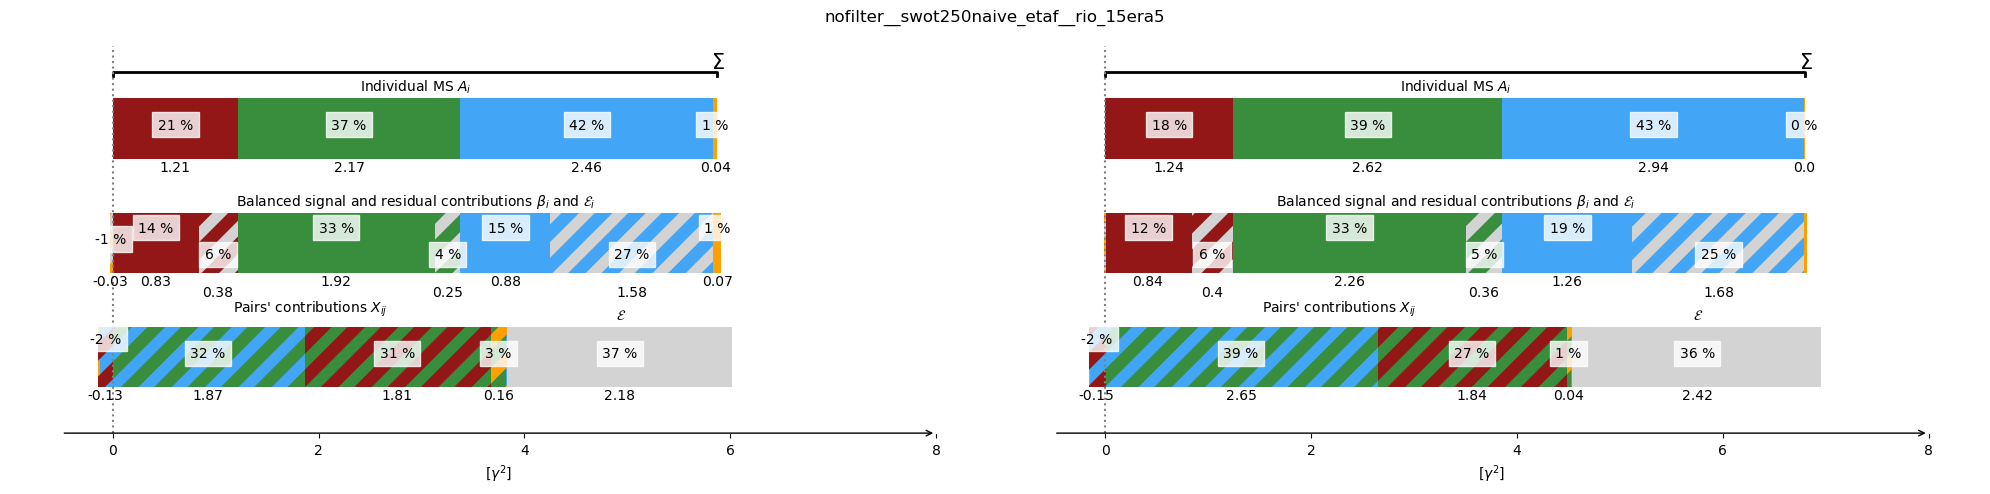

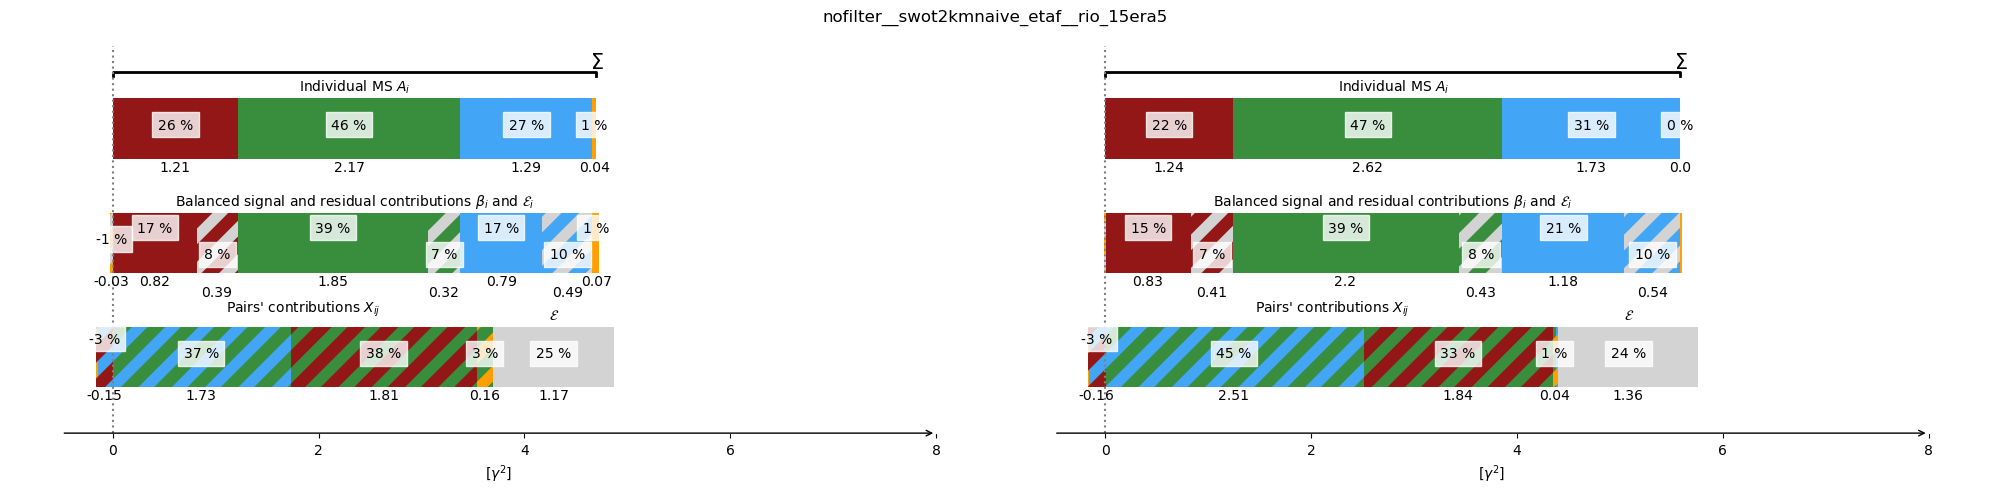

In [23]:
ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()
print(DSD.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

__________________
## Sensitivity to SWOT-250m filtering

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
7.025788504223055
7.2804475799539965
8.769876426580538
8.818816680720133
6.665989303340561
6.938616602620302
8.35134259566471
8.397585127788632
6.190465839722849
6.441871860777303
7.815365566842426
7.855570213198912
5.806342313158906
6.034874520842535
7.289641610662248
7.334497535788665
5.533283466478967
5.746233846834669
6.8624666139457435
6.916457238345978
5.331190174759487
5.5333737896756094
6.531863950101756
6.588571053830221


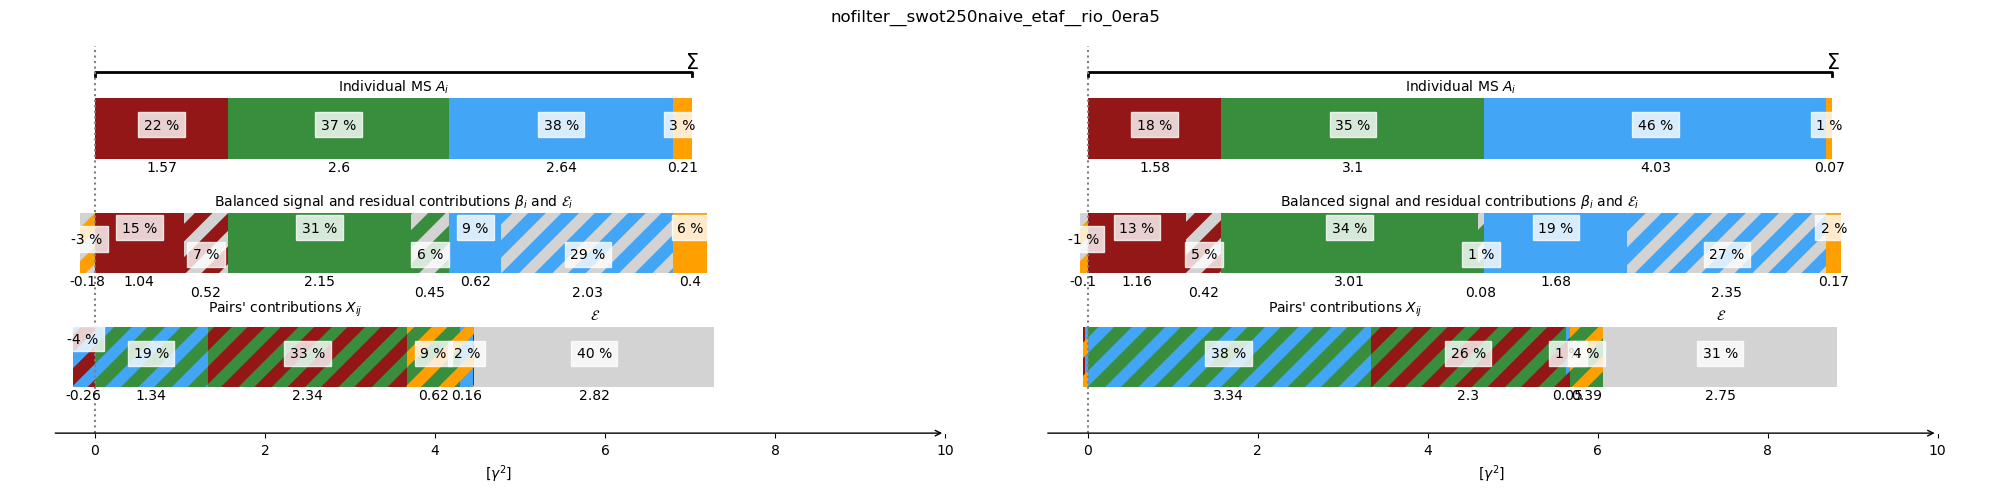

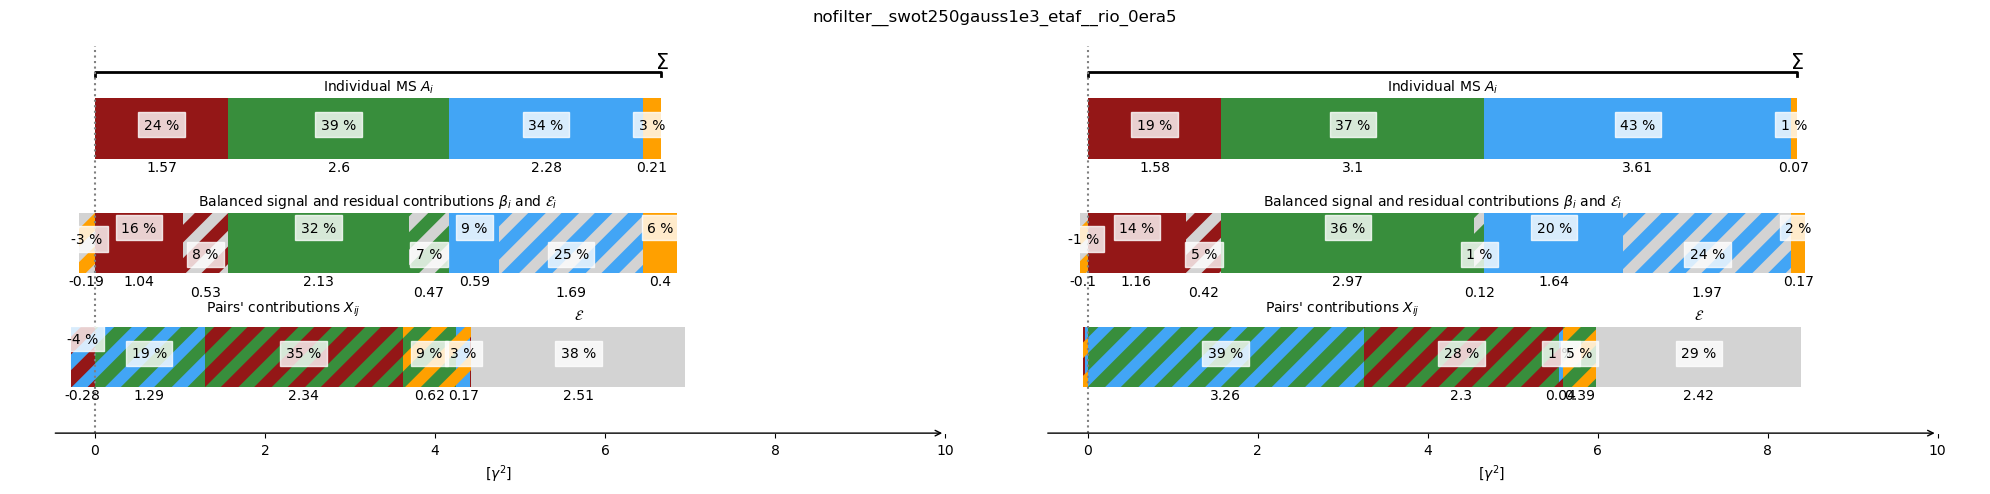

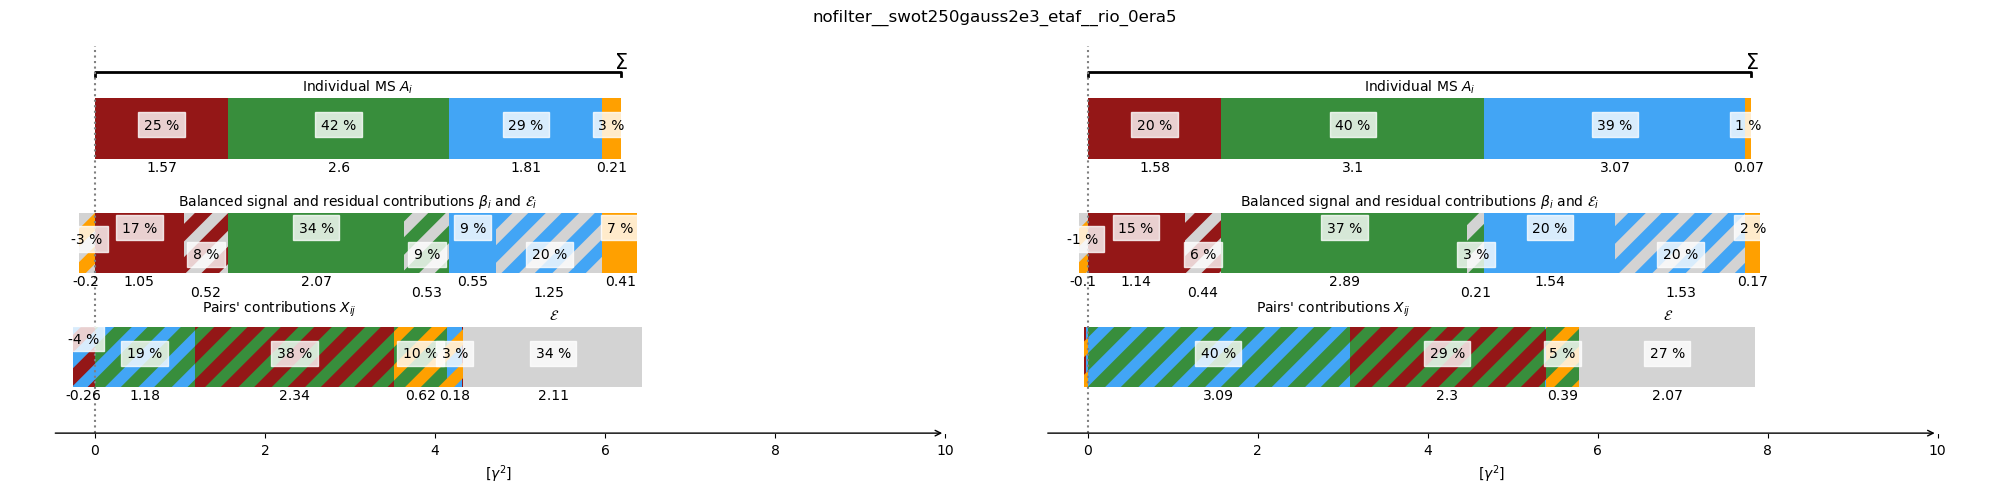

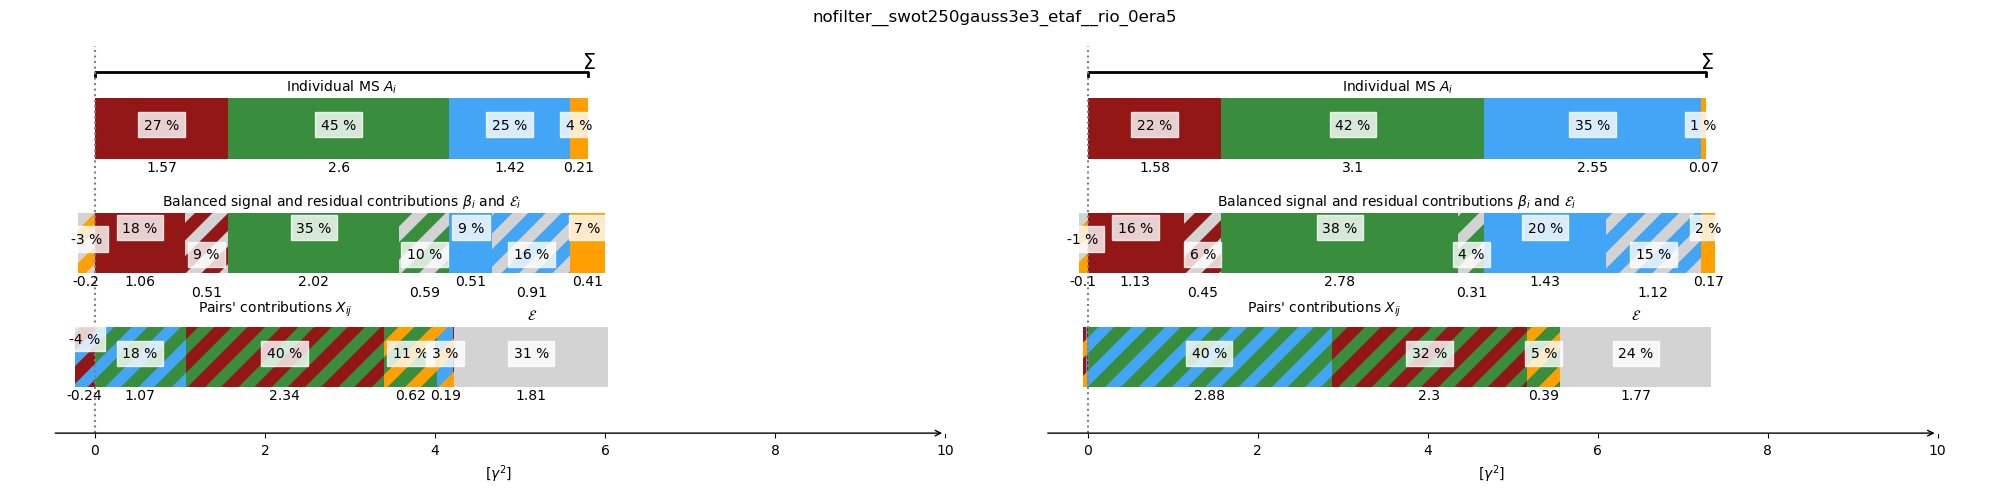

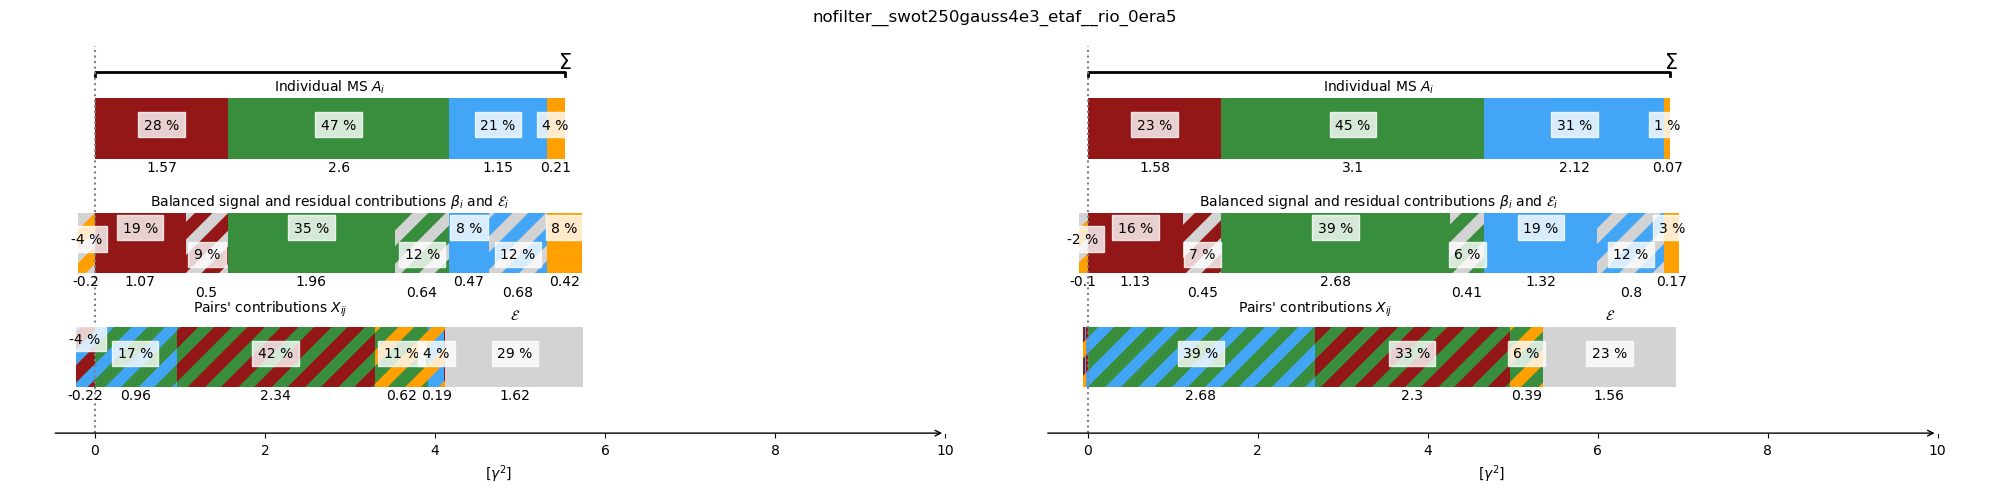

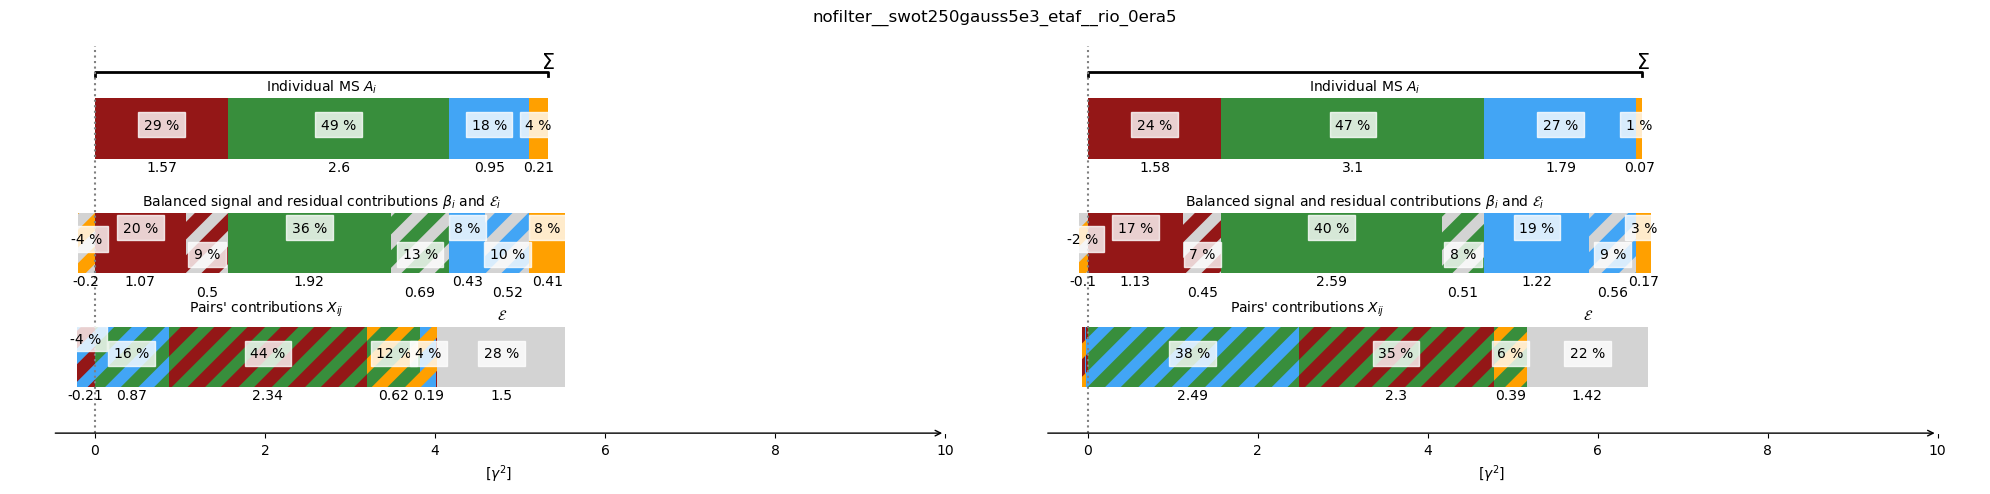

In [9]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')>12).drop_sel(row_number = err_acc).dropna('row_number')
a = 3e-4
DS = DS.where((abs(DS.ggde)<a) & (abs(DS.ggdn)<a), drop=True) #delete ggd outliers
DSS = DS.where(DS.depth==0, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))